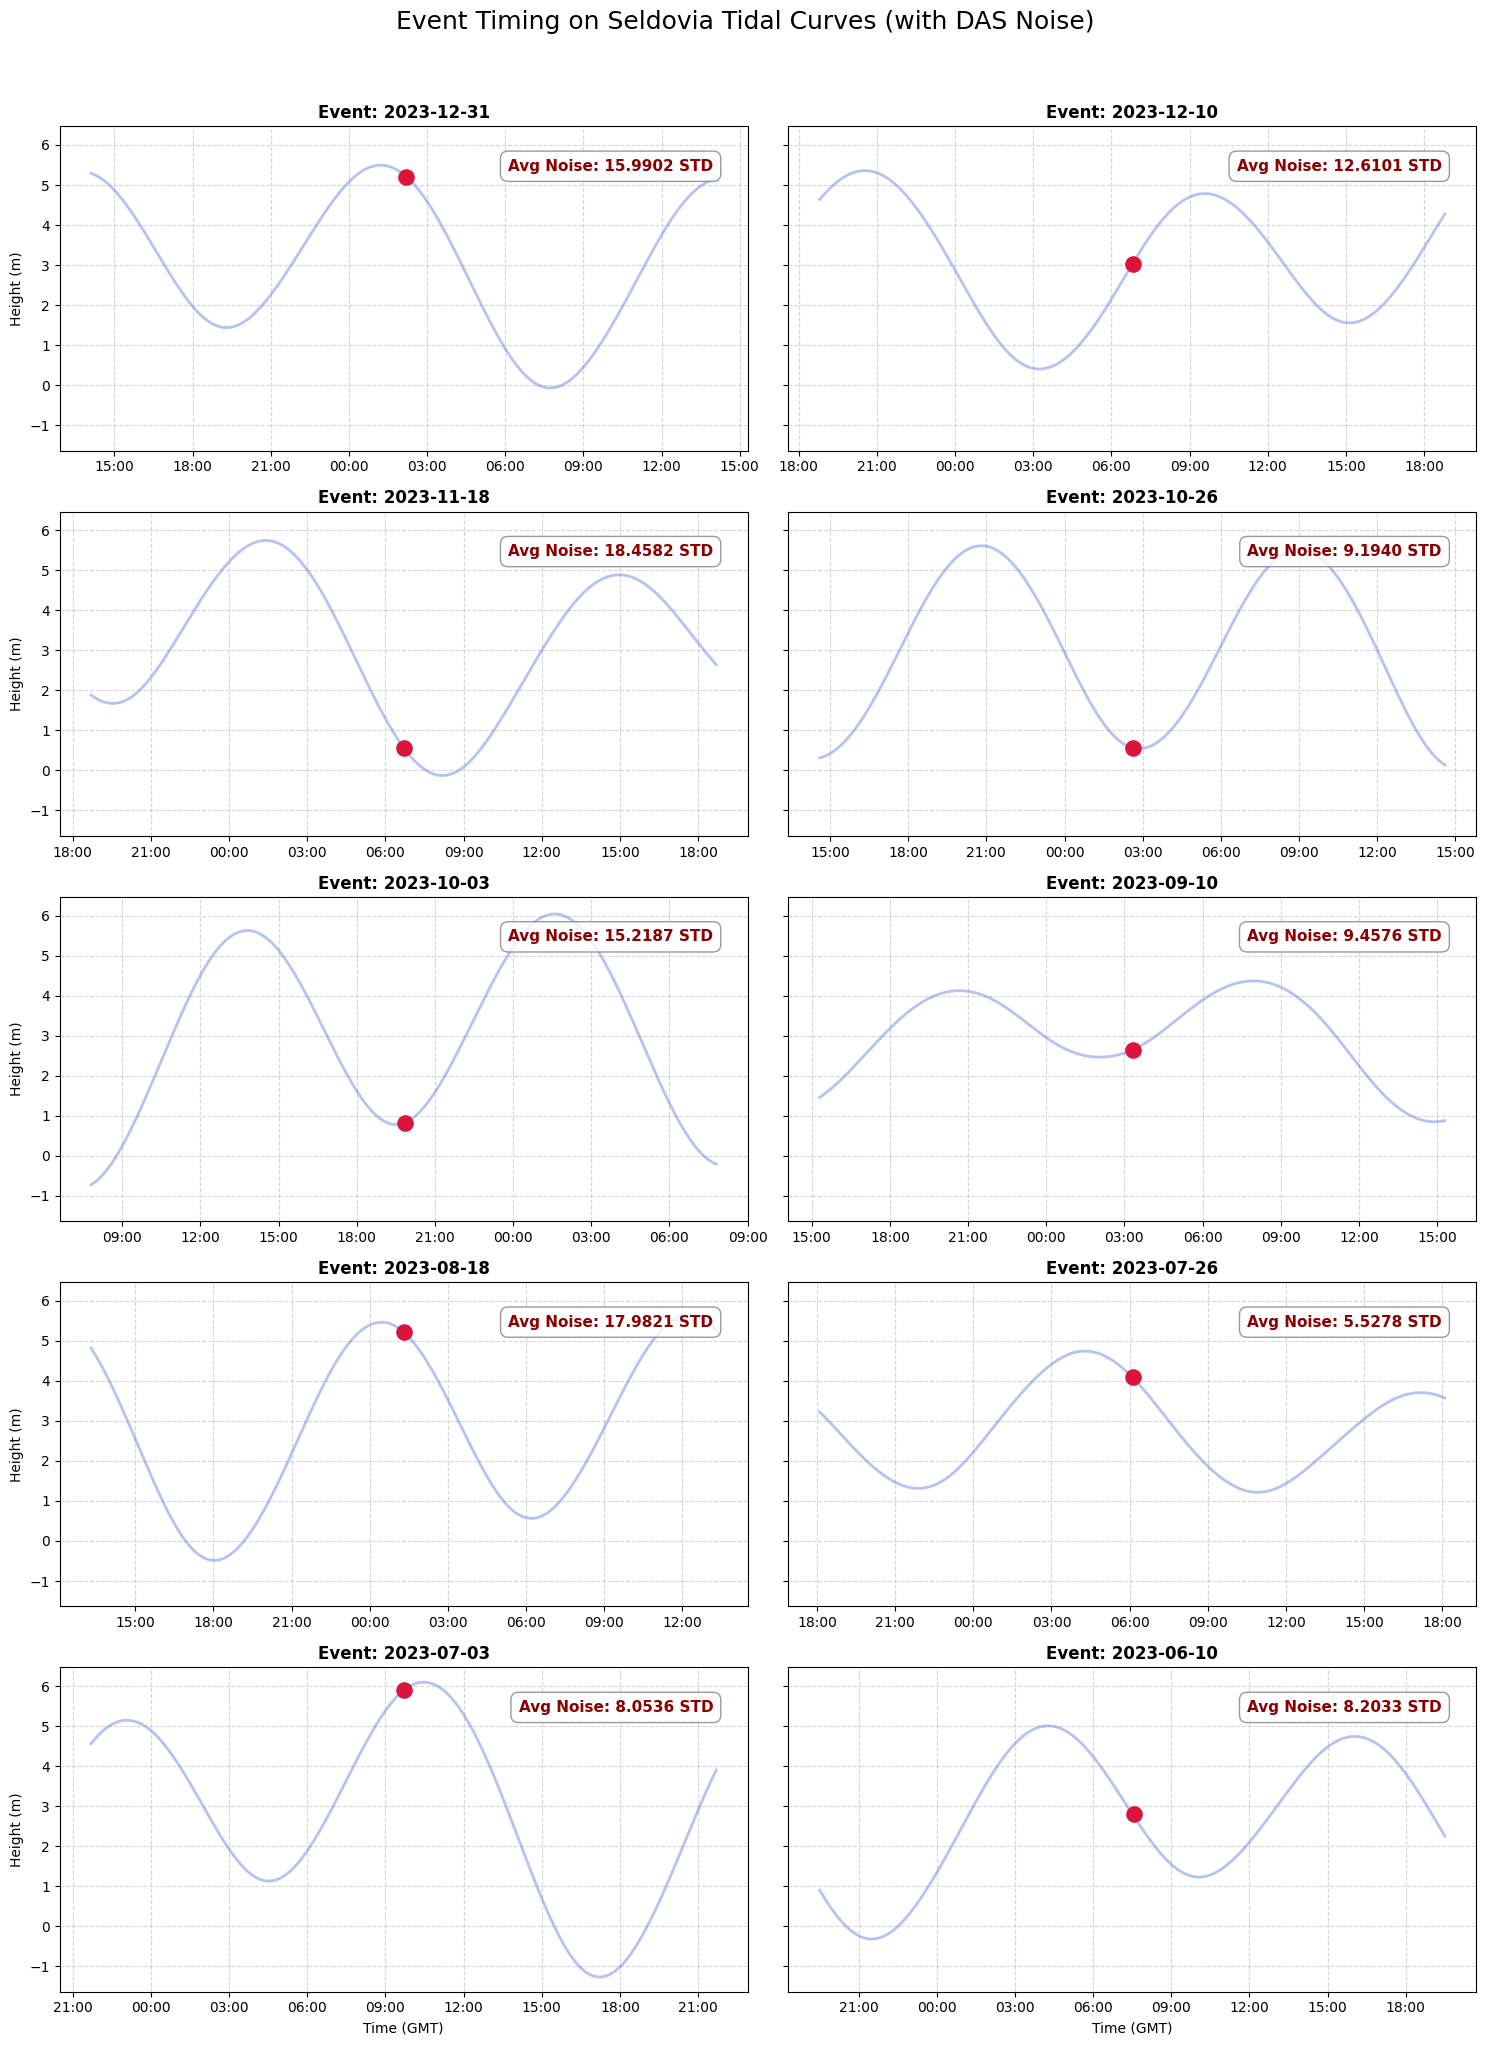


Processing complete. Figure saved as 'tidal_curves_with_noise_labels.png'.


In [6]:
# Tide curves
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import dascore as dc
import os
import requests
import time
from datetime import datetime, timedelta

base_dir = "/Users/ed/Downloads"
noise_game_dir = os.path.join(base_dir, "noise_game")
station_id = "9455500" # Seldovia

event_list = [
    "2023-12-31-02-11-56.537000ML1.5", 
    "2023-12-10-06-49-27.068000ML1.4",
    "2023-11-18-06-42-18.743000ML1.8", 
    "2023-10-26-02-36-59.823000ML1.3",
    "2023-10-03-19-50-59.443000ML1.4", 
    "2023-09-10-03-19-28.336000ML1.4",
    "2023-08-18-01-19-46.681000ML1.3", 
    "2023-07-26-06-07-07.039000ML1.2",
    "2023-07-03-09-42-42.845000ML1.5", 
    "2023-06-10-07-33-00.219000ML1.9"
]

def get_event_tide_data(event_id):
    try:
        dt = datetime.strptime(event_id[:19], '%Y-%m-%d-%H-%M-%S')
        start = (dt - timedelta(hours=12)).strftime('%Y%m%d %H:%M')
        end = (dt + timedelta(hours=12)).strftime('%Y%m%d %H:%M')
        
        url = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"
        params = {"begin_date": start, "end_date": end, "station": station_id,
                  "product": "predictions", "datum": "mllw", "time_zone": "gmt", 
                  "units": "metric", "format": "json"}
        
        data = requests.get(url, params=params).json()
        df = pd.DataFrame(data['predictions'])
        df['t'] = pd.to_datetime(df['t'])
        df['v'] = df['v'].astype(float)
        
        idx = np.argmin(np.abs(df['t'] - dt))
        return df, dt, df.iloc[idx]['v']
    except:
        return pd.DataFrame(), None, None

def get_mean_noise(file_path):
    try:
        patch = dc.spool(file_path)[0]
        t_end = patch.coords.max('time')
        sub = patch.select(time=(t_end - np.timedelta64(45, 's'), t_end)).detrend("time")
        return np.mean(sub.std(dim="time").data)
    except:
        return None

curve_data = []

for eid in event_list:
    t_df, event_dt, e_height = get_event_tide_data(eid)
    if t_df.empty: continue
    
    # Calculate noise for both cables to get an event average
    noises = []
    for cable in ["KKFLS", "TERRA"]:
        f_path = os.path.join(noise_game_dir, eid + cable)
        val = get_mean_noise(f_path)
        if val is not None: noises.append(val)
    
    avg_event_noise = np.mean(noises) if noises else 0.0
    
    curve_data.append({
        'df': t_df, 
        'event_time': event_dt, 
        'event_height': e_height, 
        'avg_noise': avg_event_noise,
        'id': eid
    })
    time.sleep(0.1)

fig, axes = plt.subplots(5, 2, figsize=(15, 20), sharey=True)
axes = axes.flatten()

for i, entry in enumerate(curve_data):
    ax = axes[i]
    ax.plot(entry['df']['t'], entry['df']['v'], color='royalblue', alpha=0.4, linewidth=2, label='Tidal Curve')
    ax.scatter(entry['event_time'], entry['event_height'], color='crimson', s=120, zorder=5, label='Event Time')
    label_text = f"Avg Noise: {entry['avg_noise']:.4f} STD"
    ax.text(0.95, 0.90, label_text, transform=ax.transAxes, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'),
            fontsize=11, fontweight='bold', color='darkred')
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_title(f"Event: {entry['id'][:10]}", fontsize=12, fontweight='bold')
    if i >= 8: ax.set_xlabel("Time (GMT)")
    if i % 2 == 0: ax.set_ylabel("Height (m)")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Event Timing on Seldovia Tidal Curves (with DAS Noise)", fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig("tidal_curves_with_noise_labels.png", dpi=300)
plt.show()

print("\nProcessing complete. Figure saved as 'tidal_curves_with_noise_labels.png'.")

In [33]:
# old DAS-window-fitting

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dascore as dc
import dascore.proc as dcp
from obspy.taup import TauPyModel
from obspy.geodetics import locations2degrees
from matplotlib.backends.backend_pdf import PdfPages
from scipy.signal import hilbert

warnings.filterwarnings("ignore")

base_project_dir = os.getcwd() 
records_path = os.path.join(base_project_dir, "das_records")
coords_file = os.path.join(base_project_dir, "das_coords_bathymetry", "KKFLS_coords.xycz")
figures_dir = os.path.join(base_project_dir, "das_figures")
os.makedirs(figures_dir, exist_ok=True)
pdf_path = os.path.join(figures_dir, "DAS_ak135_Good_Events_Window_Fitting.pdf")

model = TauPyModel(model="ak135")

larger_event_data = {
    "2023-12-31-05-22-48.221000ML3.7": {"lat": 56.111, "lon": -149.644, "dep": 10000.0},
    "2023-12-10-23-19-34.858000MB4.0": {"lat": 54.643, "lon": -161.042, "dep": 41870.0},
    "2023-11-17-19-13-52.923000ML4.2": {"lat": 56.874, "lon": -149.314, "dep": 4500.0},
    "2023-10-26-23-14-30.738000ML3.0": {"lat": 56.402, "lon": -149.316, "dep": 10000.0},
    "2023-10-03-20-41-25.720000ML3.2": {"lat": 61.174, "lon": -150.648, "dep": 53400.0},
    "2023-09-10-13-03-54.290000MB4.9": {"lat": 54.266, "lon": -160.894, "dep": 10000.0},
    "2023-08-18-05-04-44.597000ML3.4": {"lat": 61.864, "lon": -148.969, "dep": 35478.0},
    "2023-07-26-15-29-17.606000MWR4.7": {"lat": 54.621, "lon": -161.052, "dep": 36812.0},
    "2023-07-03-14-47-29.593000MWR4.5": {"lat": 61.289, "lon": -149.590, "dep": 35600.0},
    "2023-06-10-08-44-56.996000ML3.5": {"lat": 60.702, "lon": -152.084, "dep": 88800.0}
}

def load_coords(filepath):
    """Loads bathymetry coords and calculates cumulative distance."""
    df = pd.read_csv(filepath, sep=r'\s+', header=None, names=['lon','lat','cha','dep']).dropna()
    df['lon'] = df['lon'].apply(lambda x: x - 360 if x > 180 else x)
    R = 6371.0
    lat, lon = np.radians(df['lat'].values), np.radians(df['lon'].values)
    dlat, dlon = np.diff(lat), np.diff(lon)
    a = np.sin(dlat/2)**2 + np.cos(lat[:-1])*np.cos(lat[1:])*np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    df['dist_km'] = np.insert(R * c, 0, 0).cumsum()
    return df

kkfls_coords = load_coords(coords_file)
print(f"Starting processing for {len(larger_event_data)} events...")

with PdfPages(pdf_path) as pdf:
    for eid, info in larger_event_data.items():
        file_to_read = os.path.join(records_path, f"{eid}KKFLS")
        if not os.path.exists(file_to_read):
            print(f"Skipping {eid}: File not found.")
            continue

        try:
            patch = dc.read(file_to_read)[0]
            dist_len = patch.shape[patch.dims.index('distance')]
            dense_dist = np.linspace(float(patch.coords['distance'].min()), 
                                     float(patch.coords['distance'].max()), dist_len)
            patch = patch.update_coords(distance=dense_dist)
            patch = dcp.hampel_filter(patch, time=5, distance=5, samples=True, approximate=True)
            patch = dcp.decimate(patch, distance=20)
            patch = dcp.pass_filter(patch, time=(0.3, None))
            
            data_array = patch.get_array()
            envelope = np.abs(hilbert(data_array, axis=0))
            
            iso_str = f"{eid[:10]}T{eid[11:13]}:{eid[14:16]}:{eid[17:26]}"
            origin_time = np.datetime64(iso_str)
            times_sec = (patch.coords.get_array('time') - origin_time) / np.timedelta64(1, 's')
            decimated_coords = kkfls_coords.iloc[::20]
            limit = min(len(decimated_coords), data_array.shape[1])
            
            p_win_low, p_win_high = [], []
            s_win_low, s_win_high = [], []
            max_amps = []
            pick_times, pick_chans = [], []
            z_km = info['dep'] / 1000.0
            inside_s_count = 0
            valid_s_channels = 0

            for i in range(limit):
                row = decimated_coords.iloc[i]
                dist_deg = locations2degrees(info['lat'], info['lon'], row['lat'], row['lon'])
                
                arr_p = model.get_travel_times(z_km, dist_deg, phase_list=["p", "P"])
                p_t = arr_p[0].time if arr_p else np.nan
                p_win_low.append(p_t - 2)
                p_win_high.append(p_t + 4)
                
                arr_s = model.get_travel_times(z_km, dist_deg, phase_list=["s", "S"])
                s_t = arr_s[0].time if arr_s else np.nan
                s_low, s_high = s_t - 6, s_t + 15
                s_win_low.append(s_low)
                s_win_high.append(s_high)
                
                max_val = np.max(envelope[:, i])
                max_idx_time = times_sec[np.argmax(envelope[:, i])]
                max_amps.append(max_val)
                pick_times.append(max_idx_time)
                pick_chans.append(i)
                
                if not np.isnan(s_t):
                    valid_s_channels += 1
                    if s_low <= max_idx_time <= s_high:
                        inside_s_count += 1

            perc_inside = (inside_s_count / valid_s_channels * 100) if valid_s_channels > 0 else 0

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10), gridspec_kw={'width_ratios': [3, 1]})
            global_max = np.nanpercentile(np.abs(data_array), 99.5) or 1.0
            chans = np.arange(limit)
            
            for i in range(limit):
                ax1.plot(times_sec, i + (data_array[:, i] / global_max) * 2.5, color='black', lw=0.4, alpha=0.3)
            
            ax1.fill_betweenx(chans, p_win_low, p_win_high, color='blue', alpha=0.1, label='P-Window (-2s/+4s)')
            ax1.fill_betweenx(chans, s_win_low, s_win_high, color='red', alpha=0.1, label='S-Window (-6s/+15s)')
            ax1.scatter(pick_times, pick_chans, color='magenta', s=15, alpha=0.2, label='Peak Energy', zorder=5)
            
            ax1.set_title(f"{eid}\n{perc_inside:.1f}% of Max Amplitudes are within the S-window")
            ax1.set_xlabel("Time from Origin (s)")
            ax1.set_ylabel("Channel Index (Decimated)")
            ax1.invert_yaxis()
            ax1.legend(loc='upper right')
            ax1.grid(True, alpha=0.1)

            ax2.plot(max_amps, chans, color='magenta', lw=1.5)
            ax2.set_title("Peak Amplitude\nProfile")
            ax2.set_xlabel("Amplitude (Log)")
            ax2.invert_yaxis()
            ax2.grid(True, which='both', alpha=0.2)
            
            plt.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)

        except Exception as e:
            print(f"FAILED {eid}: {e}")

print(f"\nReport generated: {pdf_path}")

Starting processing for 10 events...

Report generated: /Users/ed/research_code/das/das_figures/DAS_ak135_Window_Fitting.pdf


In [ ]:
# Use AK135 predictions to create windows
#measure amplitudes
#Insert event info

#Start a habit of literature searching
#	related DAS topics, Alaska seismicity

# Figure out more on the Hempel filter, find good examples of it

In [9]:
# Res. questions
# 1) do our P and S windows accurately capture P and S phase arrivals?
# 2) do different parts of the cable routinely have stronger phase arrivals?
# 3) do the arrival amplitudes vary with backazimuth (stretch)
# 4) small earthquake very very close to cable (stretch)

# Steps
# Measure amplitude of the P and S phases
#	(i.e., inside the P and S windows)

# https://earthquake.usgs.gov/earthquakes/map/?extent=58.13592,-154.8468&extent=60.78062,-148.87024&range=search&sort=oldest&timeZone=utc&settings=true&search=%7B%22name%22:%22Search%20Results%22,%22params%22:%7B%22starttime%22:%222023-06-10%2000:00:00%22,%22endtime%22:%222023-12-31%2000:00:00%22,%22latitude%22:59.6,%22longitude%22:-152.2,%22maxradiuskm%22:150,%22minmagnitude%22:3.2,%22orderby%22:%22time%22%7D%7D

In [3]:
import os
import json
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dascore as dc
import dascore.proc as dcp
from obspy.taup import TauPyModel
from obspy.geodetics import locations2degrees
from obspy.clients.fdsn import Client
from matplotlib.backends.backend_pdf import PdfPages
from scipy.signal import hilbert

warnings.filterwarnings("ignore")

base_project_dir = os.getcwd()
records_path = os.path.join(base_project_dir, "das_records", "good-events-3.2-up")
coords_file = os.path.join(base_project_dir, "das_coords_bathymetry", "TERRA_coords.xycz")
figures_dir = os.path.join(base_project_dir, "das_figures")
cache_file = os.path.join(base_project_dir, "event_metadata_cache.json")
os.makedirs(figures_dir, exist_ok=True)

pdf_path = os.path.join(figures_dir, "TERRA_good_events_arrivals.pdf")
csv_path = os.path.join(figures_dir, "TERRA_event_amplitudes.csv")
model = TauPyModel(model="ak135")
usgs_client = Client("USGS")

good_terra_events = [
    "ak0237eejw69_TERRA.h5", "ak023aw5mbdk_TERRA.h5", "ak023eccchzy_TERRA.h5",
    "ak0237q2shdo_TERRA.h5", "ak023bebgmhd_TERRA.h5", "ak023em715sv_TERRA.h5",
    "ak02381ibekf_TERRA.h5", "ak023bhlw02w_TERRA.h5", "ak023f7eyaqg_TERRA.h5",
    "ak0238ghnzxp_TERRA.h5", "ak023bkx215x_TERRA.h5", "ak023fhgggc6_TERRA.h5",
    "ak0238qkcxek_TERRA.h5", "ak023btef8mo_TERRA.h5", "ak023fnzshe1_TERRA.h5",
    "ak0239af45c3_TERRA.h5", "ak023bzqw7a7_TERRA.h5", "ak023frilkvn_TERRA.h5",
    "ak0239lyp68s_TERRA.h5", "ak023c3206y0_TERRA.h5", "ak023g35jxin_TERRA.h5",
    "ak0239qzbmym_TERRA.h5", "ak023cgc5fmi_TERRA.h5", "ak023gbgys2j_TERRA.h5",
    "ak0239saxy95_TERRA.h5", "ak023ctiuyia_TERRA.h5", "ak023gjh7z4b_TERRA.h5",
    "ak0239vxdtm6_TERRA.h5", "ak023d3dyqv0_TERRA.h5", "ak023godcr3i_TERRA.h5",
    "ak023a0j9eo0_TERRA.h5", "ak023gqcxl3z_TERRA.h5", "ak023a7ds9th_TERRA.h5",
    "ak023dif8i7c_TERRA.h5", "ak023a91bmgs_TERRA.h5", "ak023djxyhod_TERRA.h5",
    "us6000lggw_TERRA.h5", "ak023ah9zcn5_TERRA.h5", "ak023dk7iyjo_TERRA.h5",
    "ak023asybefb_TERRA.h5", "ak023ds94esw_TERRA.h5"
]

def get_and_cache_metadata(file_list):
    if os.path.exists(cache_file):
        with open(cache_file, 'r') as j:
            return json.load(j)
    data = {}
    for f in file_list:
        eid = f.split('_')[0]
        try:
            cat = usgs_client.get_events(eventid=eid)
            origin = cat[0].origins[0]
            data[f] = {"lat": origin.latitude, "lon": origin.longitude, "dep": origin.depth, "time": str(origin.time)}
        except:
            if eid == "ak023gjh7z4b":
                data[f] = {"lat": 60.335, "lon": -151.754, "dep": 71300.0, "time": "2023-12-26T06:30:02.910"}
            elif eid == "ak023d3dyqv0":
                data[f] = {"lat": 60.320, "lon": -150.699, "dep": 79300.0, "time": "2023-10-12T03:02:49.457"}
    with open(cache_file, 'w') as j:
        json.dump(data, j, indent=4)
    return data

def load_coords(filepath):
    df = pd.read_csv(filepath, sep=r'\s+', header=None, names=['lon','lat','cha','dep']).dropna()
    df['lon'] = np.where(df['lon'] > 180, df['lon'] - 360, df['lon'])
    return df

event_metadata = get_and_cache_metadata(good_terra_events)
terra_coords = load_coords(coords_file)

event_stats = []
s_window_percentages = []

with PdfPages(pdf_path) as pdf:
    for fname, info in event_metadata.items():
        try:
            patch = dc.read(os.path.join(records_path, fname))[0]
            patch = dcp.pass_filter(patch, time=(0.3, 10.0))
            patch = dcp.decimate(patch, distance=20)
            data_array = patch.get_array()
            envelope = np.abs(hilbert(data_array, axis=0))

            origin_time = np.datetime64(info['time'].replace('Z', ''))
            times_sec = (patch.coords.get_array('time') - origin_time) / np.timedelta64(1, 's')
            decimated_coords = terra_coords.iloc[::20]
            limit = min(len(decimated_coords), data_array.shape[1])
            z_km = info['dep'] / 1000.0 

            p_win_low, p_win_high = [], []
            s_win_low, s_win_high = [], []
            max_amps = []
            p_max_amps = []
            pick_times, pick_chans = [], []
            slant_km_list = []
            inside_s_count = 0
            valid_s_channels = 0

            for i in range(limit):
                row = decimated_coords.iloc[i]
                dist_deg = locations2degrees(info['lat'], info['lon'], row['lat'], row['lon'])
                slant_km = np.hypot(dist_deg * 111.19, z_km)
                slant_km_list.append(slant_km)

                arrivals = model.get_travel_times(z_km, dist_deg, phase_list=["p", "P", "s", "S"])
                p_arr = [a.time for a in arrivals if a.name.lower() in ['p', 'pg']]
                s_arr = [a.time for a in arrivals if a.name.lower() in ['s', 'sg']]
                p_t = p_arr[0] if p_arr else np.nan
                s_t = s_arr[0] if s_arr else np.nan

                pw_l, pw_h = p_t - 2, p_t + 4
                s_low, s_high = s_t - 6, s_t + 15

                p_win_low.append(pw_l)
                p_win_high.append(pw_h)
                s_win_low.append(s_low)
                s_win_high.append(s_high)

                if not np.isnan(p_t):
                    p_mask = (times_sec >= pw_l) & (times_sec <= pw_h)
                    p_max_amps.append(np.max(envelope[p_mask, i]) if np.any(p_mask) else 0)
                else:
                    p_max_amps.append(0)

                max_val = np.max(envelope[:, i])
                max_idx_time = times_sec[np.argmax(envelope[:, i])]
                max_amps.append(max_val)
                pick_times.append(max_idx_time)
                pick_chans.append(i)

                if not np.isnan(s_t):
                    valid_s_channels += 1
                    if s_low <= max_idx_time <= s_high:
                        inside_s_count += 1

            perc_inside = (inside_s_count / valid_s_channels * 100) if valid_s_channels > 0 else 0
            s_window_percentages.append(perc_inside)

            min_slant_idx = np.argmin(slant_km_list)
            min_slant_val = slant_km_list[min_slant_idx]

            event_stats.append({
                "event_id": fname.split('_')[0],
                "perc_inside_s": perc_inside,
                "mean_p_max": np.mean(p_max_amps),
                "mean_total_max": np.mean(max_amps),
                "min_slant_km": min_slant_val
            })

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10), gridspec_kw={'width_ratios': [3, 1]})
            vmax = np.nanpercentile(np.abs(data_array), 99.5) or 1.0
            chans = np.arange(limit)

            for i in range(limit):
                ax1.plot(times_sec, i + (data_array[:, i]/vmax) * 2.5, color='black', lw=0.4, alpha=0.3)

            ax1.fill_betweenx(chans, p_win_low, p_win_high, color='blue', alpha=0.1, label='P-Window (-2s/+4s)')
            ax1.fill_betweenx(chans, s_win_low, s_win_high, color='red', alpha=0.1, label='S-Window (-6s/+15s)')
            ax1.scatter(pick_times, pick_chans, color='magenta', s=15, alpha=0.2, label='Max Energy', zorder=5)
            ax1.set_title(f"ID: {fname.split('_')[0]} | Depth: {z_km:.1f} km | Straightline Distance: {min_slant_val:.2f} km\n"
                         f"{perc_inside:.1f}% of Max Amplitudes within S-window")
            ax1.set_xlabel("Seconds from Origin")
            ax1.set_ylabel("Channel Index (Decimated x20)")
            ax1.invert_yaxis()
            ax1.legend(loc='upper right')
            ax1.grid(True, alpha=0.1)

            ax2.plot(max_amps, chans, color='magenta', lw=1.5, label='Global Max (Abs)')
            ax2.set_title("Max Absolute\nAmplitude Profile")
            ax2.set_xlabel("Amplitude")

            ax2.set_xscale('log')
            ax2.set_xlim(-1, 1000)

            ax2.invert_yaxis()
            ax2.legend(fontsize='small')
            ax2.grid(True, which='both', alpha=0.2)

            plt.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)

        except Exception as e:
            print(f"  [ERROR] {fname}: {e}")

if s_window_percentages:
    mean_val = np.mean(s_window_percentages)
    median_val = np.median(s_window_percentages)
    min_val = np.min(s_window_percentages)
    max_val = np.max(s_window_percentages)

    print("\n% Max S-Amplitudes Summary")
    print(f"Mean:   {mean_val:.2f}%")
    print(f"Median: {median_val:.2f}%")
    print(f"Range:  {min_val:.2f}% to {max_val:.2f}%")

df_results = pd.DataFrame(event_stats)
df_results.to_csv(csv_path, index=False)

print(f"PDF saved to {pdf_path}")
print(f"CSV saved to {csv_path}")


% Max S-Amplitudes Summary
Mean:   88.40%
Median: 88.89%
Range:  57.68% to 100.00%
PDF saved to /Users/ed/research_code/das/das_figures/TERRA_good_events_arrivals.pdf
CSV saved to /Users/ed/research_code/das/das_figures/TERRA_event_amplitudes.csv


In [ ]:
# See about stacking/merging nearby traces in DASCore (or some other way if possible)
# See if SoCal published their DAS research